## Data Uploading & Pre-processing

In [1]:
from sklearn.model_selection import train_test_split
import re
import nltk
nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import pandas as pd
import string
#applying sentiment function
def getsentiment(x):
    if(x==1):
        return -1*x
    else:
        return x+4
#merging datasets and column
tabledep = pd.read_csv("/Users/rohan/Desktop/rohan/HWU/Masters project and dissertation/dataset/dataset1.csv")
tabledep["label"] = tabledep["label"].apply(getsentiment)
coldep = [tabledep["message"],tabledep["label"]]
headers=["message","sentiment"]
datadep = pd.concat(coldep, axis=1,keys=headers)
print(datadep)

tablenorm = pd.read_csv("/Users/rohan/Desktop/rohan/HWU/Masters project and dissertation/dataset/dataset2.csv",encoding='latin-1',header=None)
colnorm = [tablenorm[5],tablenorm[0]]
headers=["message","sentiment"]
datanorm = pd.concat(colnorm, axis=1,keys=headers)
print(datanorm)

dataframes = [datadep,datanorm]
datatotal = pd.concat(dataframes)

print(datatotal)

# data = data.head(5000)
input_data = datatotal['message']
output_data = datatotal['sentiment']

sentence = []

WordReduced = WordNetLemmatizer()

# Stop Words Set
stopWordsSet = set(stopwords.words('english'))
# print(stopWordsSet)


# cleaning data
def data_cleaning(data_sentence):
    #removing usernames
    data_sentence = re.sub(r'@\w+', '', str(data_sentence))
    #removing non-alphanumeric characters 
    data_sentence = re.sub(r'[^\w\s]','',str(data_sentence))
    #single characters removal
    data_sentence = re.sub(r'\s+[a-zA-Z]\s+','',data_sentence)
    #extra whitespaces removal
    data_sentence = re.sub(r'\s\s+','',data_sentence)
    #removing URLs
    data_sentence = re.sub('((www.[^s]+)| (https?://[^s]))','',data_sentence)
    #converting to lowercase
    data_sentence= data_sentence.lower()
    #tokenize sentence
    data_sentence = data_sentence.split()
    #lemmatizing words
    data_sentence = [WordReduced.lemmatize(word) for word in data_sentence]
    #removing stop words
    data_sentence = [word for word in data_sentence if word not in stopWordsSet]
    #joining words back into sentence
    data_sentence = ' '.join(data_sentence)
    
    return data_sentence

datatotal["message"] = datatotal["message"].apply(lambda x: data_cleaning(x))
print(datatotal.head())
print("done")

/Users/rohan/Desktop/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
[nltk_data] Downloading package omw-1.4 to /Users/rohan/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/rohan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/rohan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                 message  sentiment
0      just had a real good moment. i missssssssss hi...          4
1             is reading manga  http://plurk.com/p/mzp1e          4
2      @comeagainjen http://twitpic.com/2y2lx - http:...          4
3      @lapcat Need to send 'em to my accountant tomo...          4
4          ADD ME ON MYSPACE!!!  myspace.com/LookThunder          4
...                                                  ...        ...
10309  No Depression by G Herbo is my mood from now o...         -1
10310  What do you do when depression succumbs the br...         -1
10311  Ketamine Nasal Spray Shows Promise Against Dep...         -1
10312  dont mistake a bad day with depression! everyo...         -1
10313                                                  0         -1

[10314 rows x 2 columns]
                                                   message  sentiment
0        @switchfoot http://twitpic.com/2y1zl - Awww, t...          0
1        is upset 

In [2]:
print(datatotal)
print(datatotal[datatotal["sentiment"] == -1]["message"])

                                                   message  sentiment
0                     hadreal good momentmissssssssss much          4
1                          reading mangahttpplurkcompmzp1e          4
2                                  httptwitpiccom2y2lxhttp          4
3        need send em accountant tomorrow oddlywasnt ev...          4
4                         add myspacemyspacecomlookthunder          4
...                                                    ...        ...
1599995                      woke school best feeling ever          4
1599996  thewdbcomvery cool hear old walt interviewsâ h...          4
1599997                     ready mojo makeover ask detail          4
1599998  happy 38th birthday boo alll time tupac amaru ...          4
1599999                               happy charitytuesday          4

[1610314 rows x 2 columns]
8000     lack understanding issmall significant part ca...
8001     told parent depression hard get genpeople unde...
8002     depre

### Cleaned dataset to use with LLM further

In [3]:
# #for using cleaned dataset with LLMs further
# file_path = "/Users/rohan/Desktop/rohan/HWU/Masters project and dissertation/dataset/cleaned_dataset.csv" 
# datatotal.to_csv(file_path, index=False)


## Training-Testing dataset for models

In [4]:
from sklearn.model_selection import train_test_split
# Splitting data into training and testing sets
input_data = datatotal["message"]
output_data = datatotal["sentiment"]
input_train, input_test, output_train, output_test = train_test_split(input_data, output_data, test_size=0.2, random_state=156654)


## Vectorizing input data

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Vectorizing input to input into model
print("start")
vectoriser = TfidfVectorizer(ngram_range=(1,2), max_features=500000)
vectoriser.fit(input_train)
input_train_vectorized = vectoriser.transform(input_train)
input_test_vectorized = vectoriser.transform(input_test)
print("done")


start
done


## Algorithms/ Models/ Traditional Methods 

### Logistic Regression

Training Logistic Regression...


/Users/rohan/Desktop/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


done
Logistic Regression predictions done


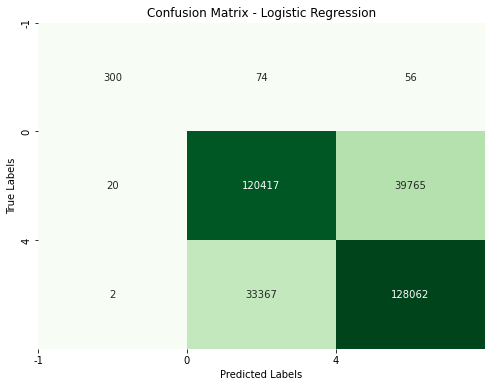

Logistic Regression Classification Report:
              precision    recall  f1-score   support

          -1       0.93      0.70      0.80       430
           0       0.78      0.75      0.77    160202
           4       0.76      0.79      0.78    161431

    accuracy                           0.77    322063
   macro avg       0.83      0.75      0.78    322063
weighted avg       0.77      0.77      0.77    322063

Logistic Regression Accuracy: 0.7724544576682202
Logistic Regression evaluation done


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
model_lr = LogisticRegression(C=2, max_iter=1000, n_jobs=-1)
# Training Logistic Regression model
print("Training Logistic Regression...")
model_lr.fit(input_train_vectorized, output_train)
print("done")
# Predictions for Logistic Regression
output_predicted_lr = model_lr.predict(input_test_vectorized)
print("Logistic Regression predictions done")

sentiment_labels = ['-1', '0', '4']

# Computing confusion matrix for Logistic Regression
cm_lr = confusion_matrix(output_test, output_predicted_lr)

# Plotting confusion matrix for Logistic Regression
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens", cbar=False)

plt.xticks(np.arange(len(sentiment_labels)), sentiment_labels)
plt.yticks(np.arange(len(sentiment_labels)), sentiment_labels)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
# Evaluating Logistic Regression
print("Logistic Regression Classification Report:")
print(classification_report(output_test, output_predicted_lr))
print("Logistic Regression Accuracy:", accuracy_score(output_test, output_predicted_lr))
print("Logistic Regression evaluation done")

### Decision tree 

Training Decision Tree...
done
Decision Tree predictions done


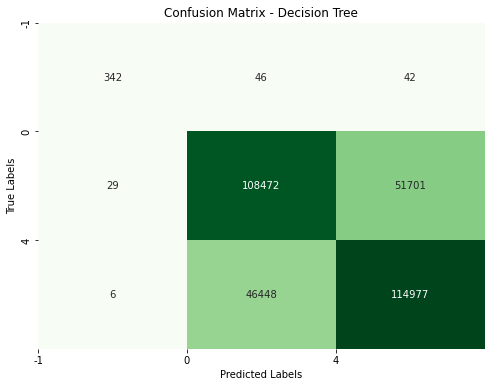

Decision Tree Classification Report:
              precision    recall  f1-score   support

          -1       0.91      0.80      0.85       430
           0       0.70      0.68      0.69    160202
           4       0.69      0.71      0.70    161431

    accuracy                           0.69    322063
   macro avg       0.77      0.73      0.75    322063
weighted avg       0.70      0.69      0.69    322063

Decision Tree Accuracy: 0.6948671533209341
Decision Tree evaluation done


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
model_dt = DecisionTreeClassifier()
# Training Decision Tree model
print("Training Decision Tree...")
model_dt.fit(input_train_vectorized, output_train)
print("done")
# Predictions for Decision Tree
output_predicted_dt = model_dt.predict(input_test_vectorized)
print("Decision Tree predictions done")

sentiment_labels = ['-1', '0', '4']

# Computing confusion matrix for Decision Tree
cm_dt = confusion_matrix(output_test, output_predicted_dt)

# Plotting confusion matrix for Decision Tree
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens", cbar=False)

plt.xticks(np.arange(len(sentiment_labels)), sentiment_labels)
plt.yticks(np.arange(len(sentiment_labels)), sentiment_labels)


plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
# Evaluation of Decision Tree
print("Decision Tree Classification Report:")
print(classification_report(output_test, output_predicted_dt))
print("Decision Tree Accuracy:", accuracy_score(output_test, output_predicted_dt))
print("Decision Tree evaluation done")


## SVM using less data

In [8]:
#seperate and less data for svm
# Reducing dataset size
input_data = datatotal["message"][:16680]
output_data = datatotal["sentiment"][:16680]
input_train, input_test, output_train, output_test = train_test_split(input_data, output_data, test_size=0.2, random_state=42)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Vectorizing input to input into model
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
vectorizer.fit(input_train)
input_train = vectorizer.transform(input_train)
input_test = vectorizer.transform(input_test)

Unique classes: [-1  0  4]
Training SVM...
SVM training done
Evaluating SVM...
SVM predictions done


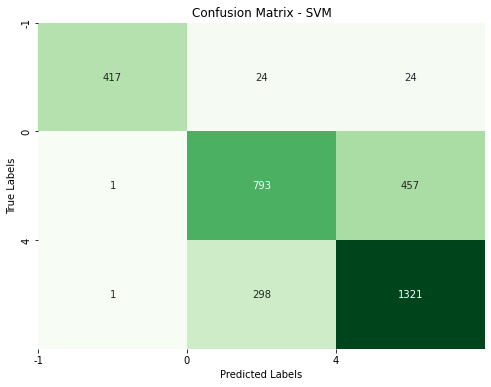

SVM Classification Report:
              precision    recall  f1-score   support

          -1       1.00      0.90      0.94       465
           0       0.71      0.63      0.67      1251
           4       0.73      0.82      0.77      1620

    accuracy                           0.76      3336
   macro avg       0.81      0.78      0.80      3336
weighted avg       0.76      0.76      0.76      3336

SVM Accuracy: 0.7586930455635491
SVM evaluation done


In [10]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.metrics import confusion_matrix
unique_classes = np.unique(output_train)
print("Unique classes:", unique_classes)
# Training SVM model
print("Training SVM...")
model_svm = SVC(kernel='linear', C=1, probability=True)
model_svm.fit(input_train, output_train)
print("SVM training done")
# Evaluating SVM
print("Evaluating SVM...")
output_predicted_svm = model_svm.predict(input_test)
print("SVM predictions done")

sentiment_labels = ['-1', '0', '4']

# Printing Confusion matrix
cm_svm = confusion_matrix(output_test, output_predicted_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens", cbar=False)

plt.xticks(np.arange(len(sentiment_labels)), sentiment_labels)
plt.yticks(np.arange(len(sentiment_labels)), sentiment_labels)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
# Printing classification report and accuracy
print("SVM Classification Report:")
print(classification_report(output_test, output_predicted_svm))
print("SVM Accuracy:", accuracy_score(output_test, output_predicted_svm))
print("SVM evaluation done")

### K-Nearest Neighbour 

Training KNN...
done
KNN predictions done


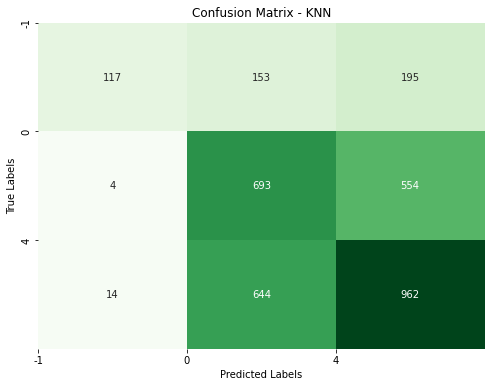

KNN Classification Report:
              precision    recall  f1-score   support

          -1       0.87      0.25      0.39       465
           0       0.47      0.55      0.51      1251
           4       0.56      0.59      0.58      1620

    accuracy                           0.53      3336
   macro avg       0.63      0.47      0.49      3336
weighted avg       0.57      0.53      0.52      3336

KNN Accuracy: 0.5311750599520384
KNN evaluation done


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
model_knn = KNeighborsClassifier(n_neighbors=4, n_jobs=-1)
# Training KNN model
print("Training KNN...")
model_knn.fit(input_train, output_train)
print("done")
# Predictions for KNN
output_predicted_knn = model_knn.predict(input_test)
print("KNN predictions done")

sentiment_labels = ['-1', '0', '4']

# Computing confusion matrix for KNN
cm_knn = confusion_matrix(output_test, output_predicted_knn)

# Plotting confusion matrix for KNN
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens", cbar=False)

plt.xticks(np.arange(len(sentiment_labels)), sentiment_labels)
plt.yticks(np.arange(len(sentiment_labels)), sentiment_labels)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
# Evaluation of KNN
print("KNN Classification Report:")
print(classification_report(output_test, output_predicted_knn))
print("KNN Accuracy:", accuracy_score(output_test, output_predicted_knn))
print("KNN evaluation done")